# Метод кросс-энтропии в обучении с подкреплением

Сначала обучим табличную стохастическую политику в `Taxi-v4`, исследуем влияние percentile и размера выборки, затем заменим таблицу нейросетью для `CartPole-v1`.

Зависимости для Python 3.12+:

```bash
python -m pip install "gymnasium[classic-control]>=1.3,<2" numpy matplotlib scikit-learn
```


In [1]:
import warnings

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore", category=ConvergenceWarning)
SEED = 42
np.random.seed(SEED)


## 1. Табличная политика для Taxi

Политика хранит вероятность каждого действия в каждом состоянии:

\[
\pi(s,a)=P(a\mid s).
\]

В начале все действия равновероятны.


In [2]:
taxi_env = gym.make("Taxi-v4", render_mode="ansi")
state, info = taxi_env.reset(seed=SEED)
n_states = taxi_env.observation_space.n
n_actions = taxi_env.action_space.n

print(taxi_env.render())
print(f"n_states={n_states}, n_actions={n_actions}")

policy = np.full((n_states, n_actions), 1.0 / n_actions)
print("Суммы вероятностей первых строк:", policy[:3].sum(axis=1))


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


n_states=500, n_actions=6
Суммы вероятностей первых строк: [1. 1. 1.]


### Генерация сессии

На каждом шаге выбираем действие из распределения текущей строки политики и сохраняем состояние, действие и суммарную награду.


In [3]:
def generate_taxi_session(env, policy, rng, t_max=10**4):
    states, actions = [], []
    total_reward = 0.0
    state, info = env.reset()

    for _ in range(t_max):
        action = rng.choice(policy.shape[1], p=policy[state])
        next_state, reward, terminated, truncated, info = env.step(action)
        states.append(state)
        actions.append(action)
        total_reward += reward
        state = next_state
        if terminated or truncated:
            break

    return states, actions, float(total_reward)

rng = np.random.default_rng(SEED)
states, actions, reward = generate_taxi_session(taxi_env, policy, rng)
print("Длина первой сессии:", len(states), "награда:", reward)


Длина первой сессии: 200 награда: -785.0


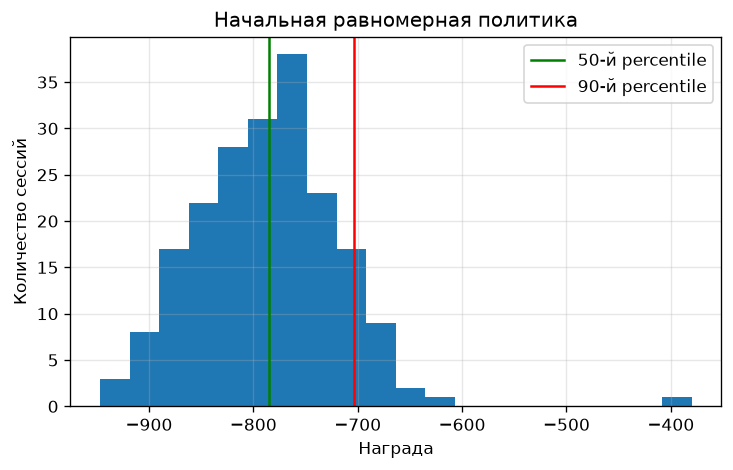

In [4]:
sample_rewards = [
    generate_taxi_session(taxi_env, policy, rng, t_max=1000)[2]
    for _ in range(200)
]

plt.figure(figsize=(7, 4))
plt.hist(sample_rewards, bins=20)
plt.axvline(np.percentile(sample_rewards, 50), label="50-й percentile", color="green")
plt.axvline(np.percentile(sample_rewards, 90), label="90-й percentile", color="red")
plt.xlabel("Награда")
plt.ylabel("Количество сессий")
plt.title("Начальная равномерная политика")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Отбор элитных сессий и обновление политики

Оставляем сессии с наградой не ниже заданного percentile. Новая вероятность действия пропорциональна числу его появлений в элитных сессиях. Для непосещённых состояний сохраняется равномерное распределение.


In [5]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    reward_threshold = np.percentile(rewards_batch, percentile)
    selected = [
        index for index, reward in enumerate(rewards_batch)
        if reward >= reward_threshold
    ]
    elite_states = np.concatenate([
        np.asarray(states_batch[index]) for index in selected
    ])
    elite_actions = np.concatenate([
        np.asarray(actions_batch[index]) for index in selected
    ])
    return elite_states, elite_actions


def update_policy(elite_states, elite_actions, n_states, n_actions):
    counts = np.zeros((n_states, n_actions), dtype=float)
    np.add.at(counts, (np.asarray(elite_states, dtype=int),
                       np.asarray(elite_actions, dtype=int)), 1)

    visits = counts.sum(axis=1, keepdims=True)
    new_policy = np.full((n_states, n_actions), 1.0 / n_actions)
    visited = visits[:, 0] > 0
    new_policy[visited] = counts[visited] / visits[visited]
    return new_policy


In [6]:
states_batch = [[1, 2, 3], [4, 2, 0, 2], [3, 1]]
actions_batch = [[0, 2, 4], [3, 2, 0, 1], [3, 3]]
rewards_batch = np.array([3, 4, 5])

elite_states, elite_actions = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=30
)
test_policy = update_policy(elite_states, elite_actions, 500, 6)

print("Элитные состояния:", elite_states)
print("Элитные действия:", elite_actions)
print("Первые строки обновлённой политики:\n", test_policy[:4, :5])


Элитные состояния: [4 2 0 2 3 1]
Элитные действия: [3 2 0 1 3 3]
Первые строки обновлённой политики:
 [[1.  0.  0.  0.  0. ]
 [0.  0.  0.  1.  0. ]
 [0.  0.5 0.5 0.  0. ]
 [0.  0.  0.  1.  0. ]]


### Цикл обучения

Параметр `preserve_unvisited=True` обновляет только состояния, встретившиеся в текущих элитных сессиях. Это важно для Taxi: стартовое состояние меняется, и небольшой батч не охватывает всю таблицу на каждой итерации.


Последняя средняя награда: -347.056


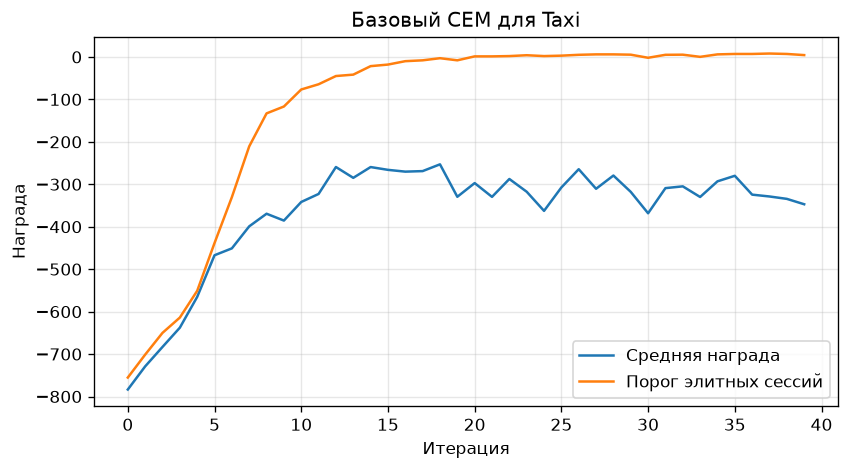

In [7]:
def train_taxi(
    n_sessions, percentile, learning_rate, n_iterations,
    seed=SEED, preserve_unvisited=False,
):
    env = gym.make("Taxi-v4")
    env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    policy = np.full((env.observation_space.n, env.action_space.n),
                     1.0 / env.action_space.n)
    mean_rewards, thresholds = [], []

    for _ in range(n_iterations):
        sessions = [
            generate_taxi_session(env, policy, rng)
            for _ in range(n_sessions)
        ]
        states_batch, actions_batch, rewards_batch = zip(*sessions)
        elite_states, elite_actions = select_elites(
            states_batch, actions_batch, rewards_batch, percentile
        )
        new_policy = update_policy(
            elite_states, elite_actions,
            env.observation_space.n, env.action_space.n,
        )

        if preserve_unvisited:
            visited = np.unique(elite_states.astype(int))
            policy[visited] = (
                learning_rate * new_policy[visited]
                + (1 - learning_rate) * policy[visited]
            )
        else:
            policy = learning_rate * new_policy + (1 - learning_rate) * policy

        mean_rewards.append(float(np.mean(rewards_batch)))
        thresholds.append(float(np.percentile(rewards_batch, percentile)))

    env.close()
    return policy, np.asarray(mean_rewards), np.asarray(thresholds)


baseline_policy, baseline_mean, baseline_threshold = train_taxi(
    n_sessions=250, percentile=70, learning_rate=0.5,
    n_iterations=40, seed=SEED,
)

plt.figure(figsize=(8, 4))
plt.plot(baseline_mean, label="Средняя награда")
plt.plot(baseline_threshold, label="Порог элитных сессий")
plt.xlabel("Итерация")
plt.ylabel("Награда")
plt.title("Базовый CEM для Taxi")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f"Последняя средняя награда: {baseline_mean[-1]:.3f}")


## 2. Влияние гиперпараметров

Сравним разные percentile при одинаковом размере батча, затем разные размеры батча при одинаковом percentile. Во всех запусках используется один seed.


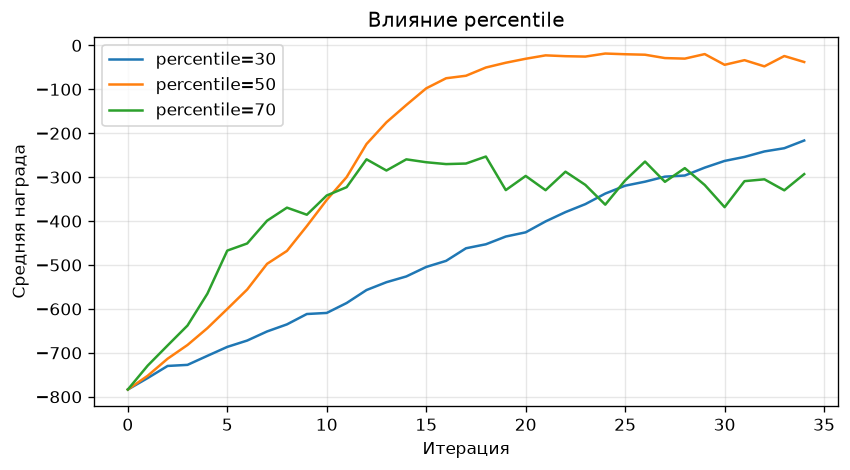

In [8]:
percentiles = [30, 50, 70]
means_by_percentile = {}

for percentile in percentiles:
    _, means, _ = train_taxi(
        n_sessions=250, percentile=percentile,
        learning_rate=0.5, n_iterations=35, seed=SEED,
    )
    means_by_percentile[percentile] = means

plt.figure(figsize=(8, 4))
for percentile, means in means_by_percentile.items():
    plt.plot(means, label=f"percentile={percentile}")
plt.xlabel("Итерация")
plt.ylabel("Средняя награда")
plt.title("Влияние percentile")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


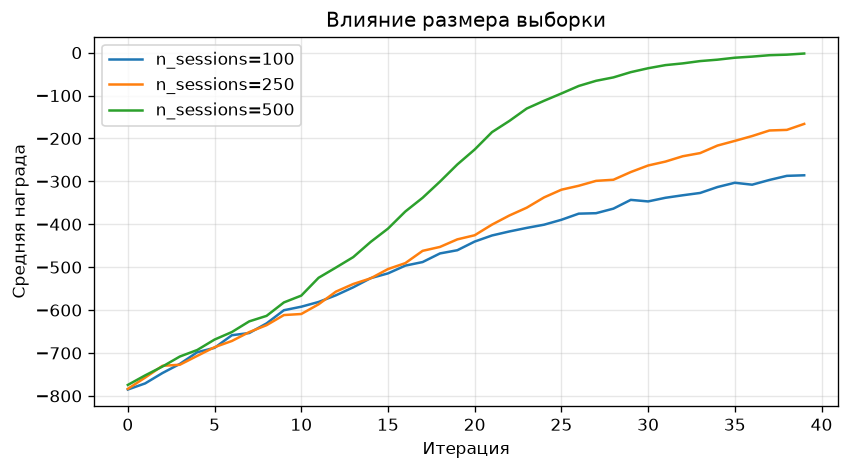

In [9]:
session_counts = [100, 250, 500]
means_by_session_count = {}

for n_sessions in session_counts:
    _, means, _ = train_taxi(
        n_sessions=n_sessions, percentile=30,
        learning_rate=0.5, n_iterations=40, seed=SEED,
    )
    means_by_session_count[n_sessions] = means

plt.figure(figsize=(8, 4))
for n_sessions, means in means_by_session_count.items():
    plt.plot(means, label=f"n_sessions={n_sessions}")
plt.xlabel("Итерация")
plt.ylabel("Средняя награда")
plt.title("Влияние размера выборки")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Настройка до положительной средней награды

Низкий percentile сохраняет более разнообразные стартовые состояния. Большой батч лучше покрывает таблицу, а сохранение непосещённых строк не стирает ранее выученные действия.


Средняя награда последних 10 итераций: 7.545


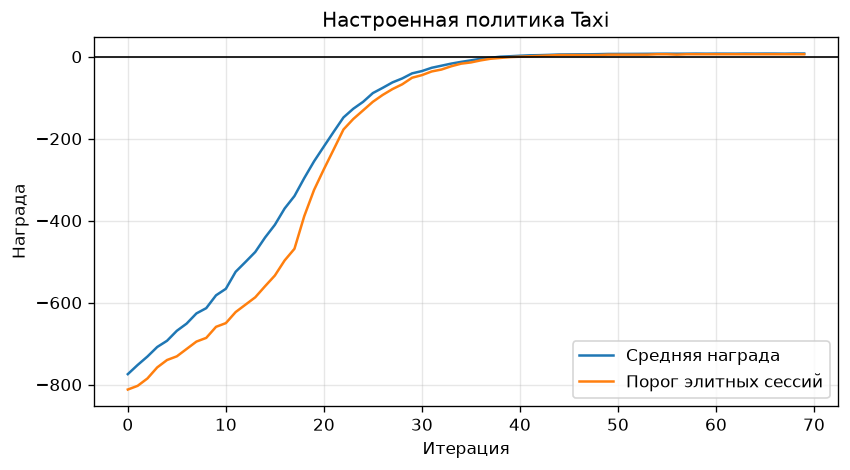

In [10]:
tuned_policy, tuned_mean, tuned_threshold = train_taxi(
    n_sessions=500,
    percentile=30,
    learning_rate=0.5,
    n_iterations=70,
    seed=SEED,
    preserve_unvisited=True,
)

plt.figure(figsize=(8, 4))
plt.plot(tuned_mean, label="Средняя награда")
plt.plot(tuned_threshold, label="Порог элитных сессий")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Итерация")
plt.ylabel("Награда")
plt.title("Настроенная политика Taxi")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Средняя награда последних 10 итераций: {tuned_mean[-10:].mean():.3f}")


### Усреднение оценки по 10 играм

Одна игра зависит от случайного старта, поэтому оцениваем итоговую политику сериями по 10 игр. Несколько таких серий показывают разброс оценки.


Среднее по 200 играм: 7.740


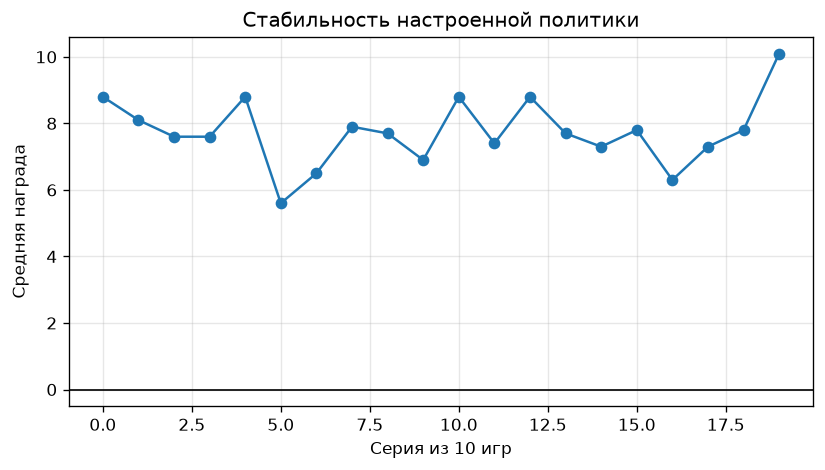

In [11]:
def evaluate_taxi_policy(policy, n_games=10, seed=1000):
    env = gym.make("Taxi-v4")
    env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    rewards = [
        generate_taxi_session(env, policy, rng)[2]
        for _ in range(n_games)
    ]
    env.close()
    return float(np.mean(rewards))


ten_game_means = np.array([
    evaluate_taxi_policy(tuned_policy, n_games=10, seed=1000 + run)
    for run in range(20)
])

plt.figure(figsize=(8, 4))
plt.plot(ten_game_means, marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Серия из 10 игр")
plt.ylabel("Средняя награда")
plt.title("Стабильность настроенной политики")
plt.grid(alpha=0.3)
plt.show()
print(f"Среднее по 200 играм: {ten_game_means.mean():.3f}")


## 3. Нейросетевая политика для CartPole

Состояние теперь является вещественным вектором, поэтому таблицу заменяем `MLPClassifier`. Сеть выдаёт вероятности действий через `predict_proba`, а обучение проводится на состояниях и действиях элитных сессий.


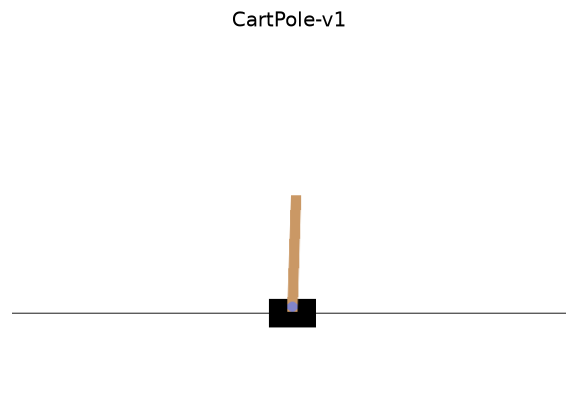

In [12]:
taxi_env.close()
cart_env = gym.make("CartPole-v1", render_mode="rgb_array")
initial_observation, info = cart_env.reset(seed=SEED)
cart_n_actions = cart_env.action_space.n

plt.figure(figsize=(6, 4))
plt.imshow(cart_env.render())
plt.axis("off")
plt.title("CartPole-v1")
plt.show()

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
    warm_start=True,
    max_iter=1,
    random_state=SEED,
)
agent.fit(
    np.repeat(initial_observation[None, :], cart_n_actions, axis=0),
    np.arange(cart_n_actions),
)


In [13]:
def generate_cartpole_session(env, agent, rng, t_max=500):
    states, actions = [], []
    total_reward = 0.0
    state, info = env.reset()

    for _ in range(t_max):
        probabilities = agent.predict_proba(np.asarray(state).reshape(1, -1))[0]
        action = rng.choice(cart_n_actions, p=probabilities)
        next_state, reward, terminated, truncated, info = env.step(action)
        states.append(state)
        actions.append(action)
        total_reward += reward
        state = next_state
        if terminated or truncated:
            break

    return states, actions, float(total_reward)


Итераций: 20
Финальная средняя награда: 221.390


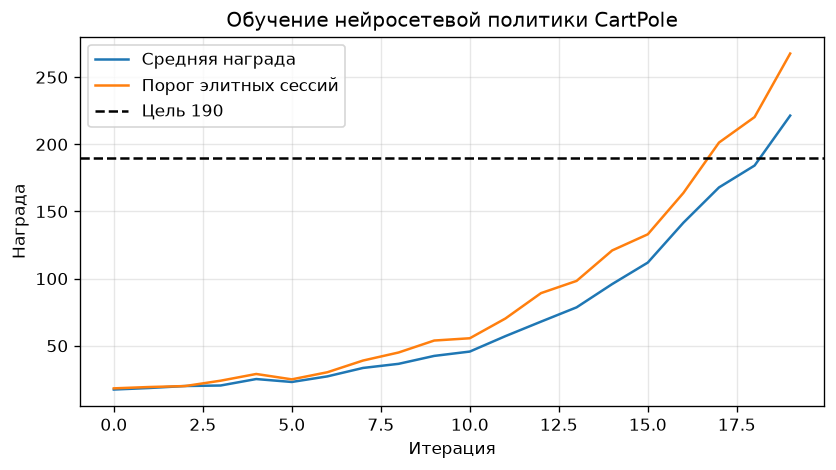

In [14]:
cart_rng = np.random.default_rng(SEED)
cart_mean_rewards = []
cart_thresholds = []
n_sessions = 100
percentile = 70

for iteration in range(60):
    sessions = [
        generate_cartpole_session(cart_env, agent, cart_rng)
        for _ in range(n_sessions)
    ]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile
    )
    agent.fit(elite_states, elite_actions)

    mean_reward = float(np.mean(rewards_batch))
    cart_mean_rewards.append(mean_reward)
    cart_thresholds.append(float(np.percentile(rewards_batch, percentile)))
    if mean_reward > 190:
        break

plt.figure(figsize=(8, 4))
plt.plot(cart_mean_rewards, label="Средняя награда")
plt.plot(cart_thresholds, label="Порог элитных сессий")
plt.axhline(190, color="black", linestyle="--", label="Цель 190")
plt.xlabel("Итерация")
plt.ylabel("Награда")
plt.title("Обучение нейросетевой политики CartPole")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Итераций:", len(cart_mean_rewards))
print(f"Финальная средняя награда: {cart_mean_rewards[-1]:.3f}")
cart_env.close()


## Итоговый отчёт

### Taxi-v3

- Базовая версия метода кросс-энтропии дала среднюю награду **-347.056** на последней итерации.
- Для устойчивого обучения использованы 500 сессий, 30-й процентиль, коэффициент обновления 0.5 и сохранение прежнего распределения действий для состояний, не попавших в элитные сессии.
- Средняя награда за последние 10 итераций обучения составила **7.545**.
- При независимой проверке на 200 играх средняя награда составила **7.740**.

### CartPole-v1

- Политика аппроксимирована нейросетью `MLPClassifier` с двумя скрытыми слоями по 20 нейронов.
- Средняя награда достигла **221.390** за 20 итераций, поэтому требование получить результат выше 190 выполнено.

Все требуемые эксперименты проведены, графики и результаты сохранены непосредственно в ноутбуке.
